In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

df = pd.read_csv('Dataset/bank-full.csv',sep=';')
df_backup = df.copy()

display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


None

In [ ]:
df_numerica = df[['age','balance','duration','campaign','pdays','previous']]

In [ ]:
display(df.sample(10))

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
24044,36,self-employed,single,tertiary,no,-103,yes,yes,telephone,17,oct,3253,1,-1,0,unknown,yes
20677,48,services,married,secondary,no,260,no,no,cellular,12,aug,228,5,-1,0,unknown,no
40362,30,technician,married,secondary,no,2326,no,no,cellular,22,jun,67,1,108,1,success,no
2640,32,blue-collar,married,secondary,no,363,yes,no,unknown,13,may,431,1,-1,0,unknown,no
36200,44,services,divorced,secondary,no,0,yes,no,cellular,11,may,151,2,370,2,failure,no
15104,58,admin.,married,secondary,no,1813,yes,no,telephone,17,jul,15,1,-1,0,unknown,no
24733,44,housemaid,divorced,secondary,no,653,no,no,cellular,17,nov,475,1,-1,0,unknown,no
4207,22,blue-collar,single,secondary,no,0,yes,no,unknown,19,may,123,1,-1,0,unknown,no
27881,36,services,married,tertiary,no,301,no,no,cellular,28,jan,333,1,-1,0,unknown,no
16119,34,technician,single,tertiary,no,228,yes,no,cellular,22,jul,387,4,-1,0,unknown,no


---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: A pessoa estar ou não devendo afeta se ela vai ou não contratar o serviço?

In [ ]:
df_binaria = df[['default','housing','loan','y']]

In [ ]:
map_bin = {'yes':1,'no':0}
df_binaria = df_binaria.replace(map_bin)

#display(df_binaria[['default','y']].value_counts())

df_default = df_binaria[['default','y']]

df_0 = df_default[df_default['default']==0]
df_1 = df_default[df_default['default']==1]

total_0 = df_0['y'].count()
print(f'Número de pessoas NÃO inadimplentes: {total_0}')
display((df_0.value_counts()/df_0['y'].count())*100)

print()

total_1 = df_1['y'].count()
print(f'Número de pessoas inadimplentes: {total_1}')
display((df_1.value_counts()/df_1['y'].count())*100)

Número de pessoas NÃO inadimplentes: 44396


C:\Users\User\AppData\Local\Temp\ipykernel_20452\986305233.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_binaria = df_binaria.replace(map_bin)


default  y
0        0    88.203892
         1    11.796108
Name: count, dtype: float64


Número de pessoas inadimplentes: 815


default  y
1        0    93.619632
         1     6.380368
Name: count, dtype: float64

O fato de ter muito menos pessoas inadimplentes afeta essa porcentagem?

CONCLUSÃO: O fato de a pessoa estar devendo ou não, não afeta muito o fato de que ela aplicou ou não o dinheiro, o que é curioso...

---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: A idade influencia se a pessoa vai ou não contratar o servicço?

SEPARAR POR FAIXA ETÁRIA

,age,y
0,18,0.583333
1,19,0.314286
2,20,0.300000
3,21,0.278481
4,22,0.310078
5,23,0.217822
6,24,0.225166
7,25,0.214421
8,26,0.166460
9,27,0.155116


,age,y
67,85,5
68,86,9
69,87,4
70,88,2
71,89,3
72,90,2
73,92,2
74,93,2
75,94,1
76,95,2


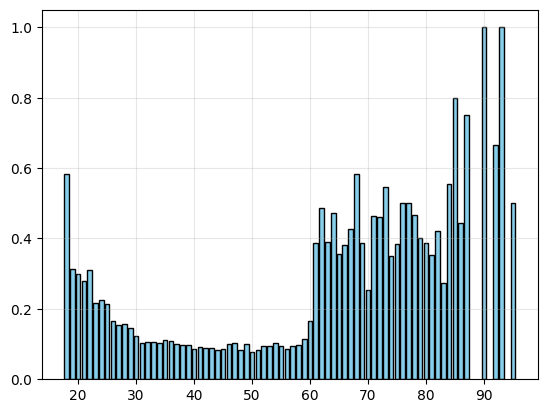

In [ ]:
df_idade = df[['age','y']]
df_yes = df_idade[df_idade['y']=='yes'].groupby('age',as_index=False).count()

df_total_por_idade = df[['age','y']].groupby('age',as_index=False).count()

df_yes['y'] = df_yes['y'] / df_total_por_idade['y']

display(df_yes.head(10))
display(df_total_por_idade.tail(10))

plt.figure()
plt.grid(alpha=0.3)

bin = df_yes['age'].max() - df_yes['age'].min()

plt.bar(x=df_yes['age'],height=df_yes['y'],color='skyblue',edgecolor='black')
plt.show()

---------------------------------------------------------------------------------------------------------------------------------------------

PERGUNTA: O nível de escolaridade afeta se a pessoa vai fazer a aplicação?

In [ ]:
display(df.sample(10))